# 05 DenseNet121 Baseline
Model setting:
- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 1e-4
- Batch size: 32
- Max epochs: 30
- Early stopping patience: 7
- Best model selection: validation QWK 


In [7]:
EXPERIMENT_NAME = "densenet121_focal_loss_gamma15_adamw"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)

Experiment: densenet121_focal_loss_gamma15_adamw


In [8]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: D:\760-Group1-main\wanqian
Project root: D:\760-Group1-main
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [9]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cpu
Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [10]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [11]:
# Focal Loss + AdamW

import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none",
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


criterion = FocalLoss(gamma=1.5)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print("Loss function: Focal Loss, gamma=1.5")
print("Optimizer: AdamW")

Loss function: Focal Loss, gamma=1.5
Optimizer: AdamW


## create densenet

In [12]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.9476 | Train Acc: 0.4092 | Train Macro F1: 0.3388 | Train QWK: 0.3276
Val Loss:   0.7320 | Val Acc:   0.5685 | Val Macro F1: 0.4403 | Val QWK:   0.6174 | Val MAE:   0.7260
New best model found at epoch 1.
Best val qwk: 0.6174
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_focal_loss_gamma15_adamw.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0537 | Train Acc: 0.9580 | Train Macro F1: 0.9600 | Train QWK: 0.9787
Val Loss:   0.3329 | Val Acc:   0.8219 | Val Macro F1: 0.8080 | Val QWK:   0.8858 | Val MAE:   0.2534
No improvement in val qwk. Patience: 6/7

Epoch 23/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0534 | Train Acc: 0.9600 | Train Macro F1: 0.9578 | Train QWK: 0.9782
Val Loss:   0.3337 | Val Acc:   0.7603 | Val Macro F1: 0.7582 | Val QWK:   0.8622 | Val MAE:   0.3219
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 16
Best val qwk: 0.9090


In [13]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

print("Saved history to:", history_path)
history_df

Saved history to: D:\760-Group1-main\outputs\results\densenet121_focal_loss_gamma15_adamw_history.csv


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.947595,0.732029,0,0,0.409180,0.338826,0.379698,1.109375,0.327604,...,0.440264,0.507834,0.726027,0.617434,63,33,30,0.431507,0.226027,0.205479
1,2,0.553307,0.458322,1,0,0.657227,0.610073,0.648628,0.494141,0.775623,...,0.640312,0.679748,0.424658,0.805012,44,32,12,0.301370,0.219178,0.082192
2,3,0.410469,0.444741,2,0,0.719727,0.675753,0.707126,0.382812,0.839439,...,0.654013,0.648350,0.417808,0.845350,48,38,10,0.328767,0.260274,0.068493
3,4,0.315979,0.418845,3,0,0.777344,0.759070,0.774862,0.285156,0.888943,...,0.689480,0.693313,0.383562,0.852157,44,35,9,0.301370,0.239726,0.061644
4,5,0.234423,0.426088,4,0,0.824219,0.818569,0.824248,0.215820,0.920042,...,0.678931,0.687601,0.410959,0.836151,46,35,11,0.315068,0.239726,0.075342
5,6,0.225958,0.378546,4,1,0.820312,0.809987,0.818608,0.232422,0.909337,...,0.711690,0.732731,0.356164,0.839686,38,29,9,0.260274,0.198630,0.061644
6,7,0.183254,0.337342,4,2,0.857422,0.852408,0.857330,0.180664,0.930657,...,0.785076,0.801882,0.260274,0.893706,29,23,6,0.198630,0.157534,0.041096
7,8,0.146721,0.369405,7,0,0.902344,0.897933,0.902505,0.123047,0.953905,...,0.717865,0.727854,0.376712,0.833778,40,29,11,0.273973,0.198630,0.075342
8,9,0.133744,0.311958,7,1,0.895508,0.892347,0.895038,0.130859,0.950658,...,0.776740,0.790093,0.267123,0.894205,30,23,7,0.205479,0.157534,0.047945
9,10,0.129567,0.332679,9,0,0.909180,0.906548,0.909006,0.119141,0.953827,...,0.763240,0.779796,0.294521,0.876566,32,25,7,0.219178,0.171233,0.047945


## best epoch 

In [14]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                  16.000000
val_loss                0.278440
val_accuracy            0.835616
val_macro_f1            0.816445
val_weighted_f1         0.832307
val_mae                 0.212329
val_qwk                 0.909024
val_adjacent_errors    20.000000
val_distant_errors      4.000000
Name: 15, dtype: float64


## train model

In [15]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_baseline.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0664 | Train Acc: 0.9502 | Train Macro F1: 0.9511 | Train QWK: 0.9679
Val Loss:   0.4370 | Val Acc:   0.7945 | Val Macro F1: 0.7693 | Val QWK:   0.8649 | Val MAE:   0.2877
New best model found at epoch 1.
Best val qwk: 0.8649
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_ce_baseline.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0529 | Train Acc: 0.9648 | Train Macro F1: 0.9629 | Train QWK: 0.9842
Val Loss:   0.3226 | Val Acc:   0.8014 | Val Macro F1: 0.7819 | Val QWK:   0.8999 | Val MAE:   0.2603
New best model found at epoch 9.
Best val qwk: 0.8999
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_ce_baseline.pth

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0460 | Train Acc: 0.9658 | Train Macro F1: 0.9662 | Train QWK: 0.9840
Val Loss:   0.3708 | Val Acc:   0.8356 | Val Macro F1: 0.8259 | Val QWK:   0.9279 | Val MAE:   0.1986
New best model found at epoch 10.
Best val qwk: 0.9279
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_ce_baseline.pth


save history

In [16]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_baseline_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.066359,0.436950,0,0,0.950195,0.951133,0.950121,0.071289,0.967915,...,0.769270,0.785217,0.287671,0.864881,30,23,7,0.205479,0.157534,0.047945
1,2,0.077237,0.395517,1,0,0.938477,0.939942,0.938564,0.079102,0.969610,...,0.753621,0.764073,0.321918,0.866816,34,24,10,0.232877,0.164384,0.068493
2,3,0.092538,0.446011,2,0,0.930664,0.929681,0.930672,0.099609,0.956424,...,0.722550,0.744240,0.342466,0.851612,35,24,11,0.239726,0.164384,0.075342
3,4,0.065911,0.426422,2,1,0.949219,0.946474,0.949220,0.067383,0.971859,...,0.753203,0.751641,0.321918,0.871908,37,30,7,0.253425,0.205479,0.047945
4,5,0.060035,0.341327,4,0,0.959961,0.959303,0.959976,0.063477,0.969026,...,0.789496,0.803601,0.287671,0.874808,28,18,10,0.191781,0.123288,0.068493
5,6,0.050417,0.345182,5,0,0.959961,0.962538,0.960025,0.051758,0.979213,...,0.794649,0.817576,0.273973,0.877609,26,16,10,0.178082,0.109589,0.068493
6,7,0.046922,0.402823,6,0,0.964844,0.964891,0.964962,0.048828,0.979467,...,0.750297,0.768942,0.321918,0.857680,33,24,9,0.226027,0.164384,0.061644
7,8,0.050404,0.397595,6,1,0.957031,0.955349,0.957063,0.055664,0.978234,...,0.773369,0.776817,0.280822,0.892934,33,27,6,0.226027,0.184932,0.041096
8,9,0.052869,0.322645,8,0,0.964844,0.962854,0.964861,0.043945,0.984201,...,0.781921,0.794235,0.260274,0.899867,29,22,7,0.198630,0.150685,0.047945
9,10,0.046047,0.370829,9,0,0.965820,0.966235,0.965799,0.042969,0.984022,...,0.825927,0.834034,0.198630,0.927892,24,20,4,0.164384,0.136986,0.027397


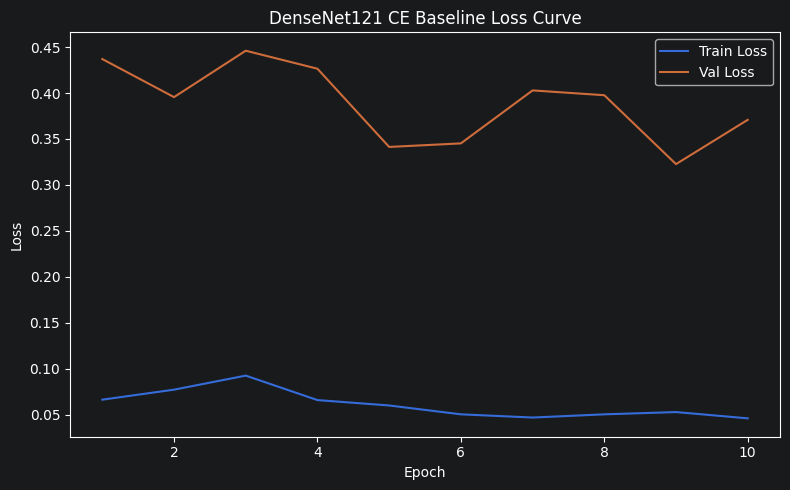

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_ce_baseline_loss.png


In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE Baseline Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_baseline_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [18]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.8356
macro_f1: 0.8259
weighted_f1: 0.8340
mae: 0.1986
qwk: 0.9279
total_errors: 24
adjacent_errors: 20
distant_errors: 4
total_error_rate: 0.1644
adjacent_error_rate: 0.1370
distant_error_rate: 0.0274


In [19]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7891
macro_f1: 0.7722
weighted_f1: 0.7874
mae: 0.2755
qwk: 0.8887
total_errors: 62
adjacent_errors: 48
distant_errors: 14
total_error_rate: 0.2109
adjacent_error_rate: 0.1633
distant_error_rate: 0.0476
              precision    recall  f1-score   support

     0Normal       0.84      0.87      0.85        91
   1Doubtful       0.78      0.76      0.77        88
       2Mild       0.62      0.55      0.58        38
   3Moderate       0.75      0.86      0.80        35
     4Severe       0.88      0.83      0.85        42

    accuracy                           0.79       294
   macro avg       0.77      0.77      0.77       294
weighted avg       0.79      0.79      0.79       294



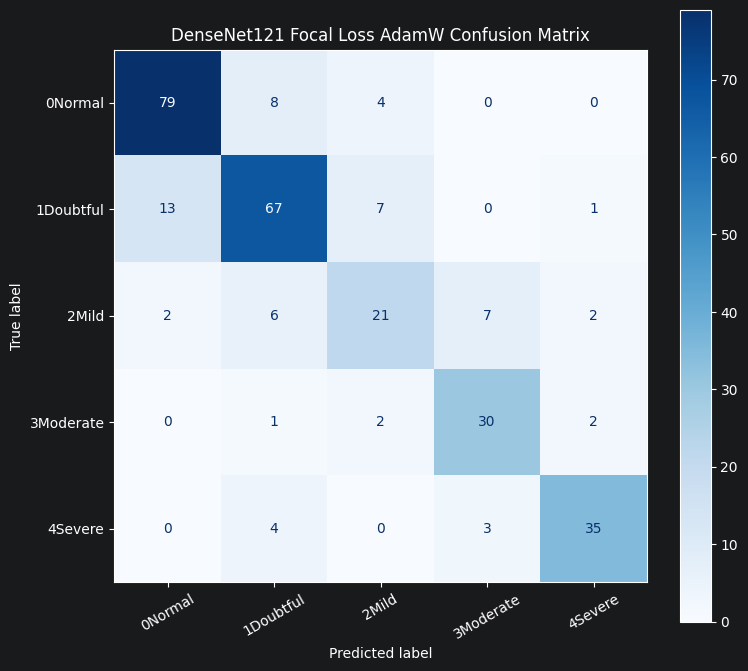

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_focal_loss_gamma15_adamw_confusion_matrix.png


In [20]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Focal Loss AdamW Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
